# LLM Text Embedding Dimensionality Ablation (128 vs 256 vs 768)

**Motivation**: the trained R-GCN checkpoint has `hidden_dim = 256`. The
existing 128-d projected text embeddings (Phase 2a) cannot be combined with
R-GCN node embeddings at the feature level (Phase 3) without re-projection.
This notebook re-encodes all four description tiers at **256-d** with the
same nonlinear AE projection, saves them under a separate output directory
(`data/embeddings_256/`) so existing 128-d caches are not overwritten, and
verifies that 256-d is at least as good as 128-d on both proxy MRR (train)
and oracle-β test MRR.

**Encoder**: BiolinkBERT (selected by Section 2 of `late_fusion_pipeline.ipynb`).
**Projection**: nonlinear AE (256-d hidden, 100 epochs, Adam lr=1e-3) — only
this projection is run because `nonlinear_ae` won the encoder/projection
selection grid for both Tier 2 and Hybrid; PCA / linear / none are skipped.

**Comparison axes**:
- 4 description tiers: `tier1`, `tier2`, `gpt4o`, `hybrid`
- 3 dimensionalities: 128 (existing), **256 (new, this notebook)**, 768 (no projection, existing for tiers ≥ 2)

**Output**:
- `data/embeddings_256/biolinkbert/{tier}/nonlinear_ae/{drug,phenotype}_embeddings.pt`
- `results/tables/dim_ablation_proxy_mrr.csv`
- `results/tables/dim_ablation_test_mrr.csv`


## 0. Setup

In [1]:
!pip install -q transformers torch torch-geometric scikit-learn scipy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys
PROJECT = "/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702"
sys.path.insert(0, PROJECT)
%cd {PROJECT}


Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/16u6rgAZFbJh8HQhxtjFa2_tq8qbi6dht/BMI702


In [3]:
import json
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

ENCODER       = "biolinkbert"
PROJECTION    = "nonlinear_ae"
TARGET_DIM    = 256
TIERS         = ["tier1", "tier2", "gpt4o", "hybrid"]
SRC_EMBED_DIR = Path("data/embeddings")          # existing 128-d + 768-d (none)
NEW_EMBED_DIR = Path("data/embeddings_256")      # this notebook's output
NEW_EMBED_DIR.mkdir(parents=True, exist_ok=True)


Device: cuda


---
## 1. Encode all 4 tiers at 256-d nonlinear AE

Each invocation of `cache_embeddings.py` runs ~3-5 min on a Colab GPU
(BiolinkBERT forward + 100-epoch nonlinear AE on the combined drug+phenotype
embedding matrix). Total expected runtime: **~15-20 min for 4 tiers**.

Saves to `data/embeddings_256/biolinkbert/{tier}/nonlinear_ae/` so the
existing `data/embeddings/biolinkbert/{tier}/{nonlinear_ae,none}/` caches
are untouched.

In [4]:
# Encode each tier at 256-d. Skips tiers that already have a cached file
# under data/embeddings_256/ to allow safe re-runs of this cell.
for tier in TIERS:
    out_dir = NEW_EMBED_DIR / ENCODER / tier / PROJECTION
    drug_pt = out_dir / "drug_embeddings.pt"
    if drug_pt.exists():
        print(f"\n[{tier}] already cached at {drug_pt} — skipping")
        continue
    print(f"\n{'='*70}\n[{tier}] encoding -> {out_dir}\n{'='*70}")
    !python scripts/cache_embeddings.py \
        --desc-dir data/descriptions \
        --output-dir {NEW_EMBED_DIR} \
        --encoder {ENCODER} \
        --tier {tier} \
        --projection {PROJECTION} \
        --target-dim {TARGET_DIM} \
        --device cuda



[tier1] encoding -> data/embeddings_256/biolinkbert/tier1/nonlinear_ae
INFO: Encoder: biolinkbert (michiyasunaga/BioLinkBERT-base)
INFO: Pooling: mean
INFO: Tier: tier1, Projection: nonlinear_ae
INFO: Seed: 42
INFO: Loading drugs descriptions from data/descriptions/drugs_tier1.json
INFO: Loaded 7957 drugs descriptions
INFO: Encoding drugs with biolinkbert...
INFO: NumExpr defaulting to 2 threads.
INFO: HTTP Request: HEAD https://huggingface.co/michiyasunaga/BioLinkBERT-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/michiyasunaga/BioLinkBERT-base/b71f5d70f063d1c8f1124070ce86f1ee463ca1fe/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/michiyasunaga/BioLinkBERT-base/b71f5d70f063d1c8f1124070ce86f1ee463ca1fe/config.json "HTTP/1.1 200 OK"
config.json: 100% 559/559 [00:00<00:00, 2.39MB/s]
INFO: HTTP Request: HEAD https://huggingface.co/michiyasunaga/

In [5]:
# Verify shapes, ordering, and labeling of all saved 256-d files
print(f"=== Verifying 256-d cached files under {NEW_EMBED_DIR} ===\n")
verify_rows = []
for tier in TIERS:
    out_dir = NEW_EMBED_DIR / ENCODER / tier / PROJECTION
    for entity in ["drug", "phenotype"]:
        pt = out_dir / f"{entity}_embeddings.pt"
        if not pt.exists():
            verify_rows.append({"tier": tier, "entity": entity, "exists": False})
            continue
        d = torch.load(pt, map_location="cpu", weights_only=False)
        emb = d["embeddings"]
        idx = d["node_indices"]
        # L2 norm check (should be ~1 since cache_embeddings.py L2-normalizes)
        norms = emb.norm(dim=-1)
        verify_rows.append({
            "tier": tier,
            "entity": entity,
            "n_rows": int(emb.shape[0]),
            "dim": int(emb.shape[1]),
            "n_indices": len(idx),
            "L2_norm_mean": float(norms.mean()),
            "L2_norm_std": float(norms.std()),
            "indices_sorted": list(idx) == sorted(idx),
        })

verify_df = pd.DataFrame(verify_rows)
print(verify_df.to_string(index=False))

# Sanity: every row must be exactly 256-d, L2-normalized, indices sorted
assert (verify_df["dim"] == 256).all(),       "Some files are not 256-d"
assert (verify_df["L2_norm_mean"] - 1.0).abs().max() < 1e-3, "L2 norm not ~1"
assert verify_df["indices_sorted"].all(),     "Some files have unsorted indices"
print("\n✓ All 256-d caches verified: dim=256, L2-normalized, indices sorted")


=== Verifying 256-d cached files under data/embeddings_256 ===

  tier    entity  n_rows  dim  n_indices  L2_norm_mean  L2_norm_std  indices_sorted
 tier1      drug    7957  256       7957           1.0 4.689601e-08            True
 tier1 phenotype    3518  256       3518           1.0 4.951409e-08            True
 tier2      drug    7957  256       7957           1.0 4.769383e-08            True
 tier2 phenotype    3518  256       3518           1.0 4.543958e-08            True
 gpt4o      drug    7957  256       7957           1.0 4.428574e-08            True
 gpt4o phenotype    3518  256       3518           1.0 4.318270e-08            True
hybrid      drug    7957  256       7957           1.0 4.245825e-08            True
hybrid phenotype    3518  256       3518           1.0 4.307730e-08            True

✓ All 256-d caches verified: dim=256, L2-normalized, indices sorted


---
## 2. Load supervision data and graph_scores

In [4]:
from src.data.primekg_loader import (
    load_primekg, mask_test_diseases, build_pyg_graph, build_supervision_maps,
)
from src.data.disease_split import load_split
from src.evaluation.late_fusion_eval import (
    load_graph_scores, load_llm_scores, _build_drug_degree,
    _extract_state_dict, _infer_arch_from_state_dict, _pick_num_heads,
    evaluate_single_beta,
)
from src.models.cross_attention_scorer import PhenoDrugModel
from src.models.fusion import normalize_scores
from src.evaluation.metrics import reciprocal_rank, recall_at_k

CHECKPOINT_PATH = "data/weights/rgcn_best_model.pt"
assert Path(CHECKPOINT_PATH).exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"

# Data + supervision
nodes_df, edges_df, kg_df = load_primekg("data/primekg")
train_diseases, test_diseases, train_pairs, test_pairs = load_split("data/splits")
supervision = build_supervision_maps(
    kg_df, nodes_df, train_diseases, test_diseases, train_pairs, test_pairs
)
disease_to_phenotypes  = supervision["disease_to_phenotypes"]
train_disease_to_drugs = supervision["train_disease_to_drugs"]
test_disease_to_drugs  = supervision["test_disease_to_drugs"]
drug_indices_arr       = np.array(sorted(supervision["drug_indices"]))
drug_degree            = _build_drug_degree(train_pairs)

print(f"Train diseases: {len(train_diseases)}  Test diseases: {len(test_diseases)}")
print(f"Drug nodes: {len(drug_indices_arr)}")


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


Train diseases: 431  Test diseases: 108
Drug nodes: 7957


In [5]:
# Load R-GCN model + compute graph_scores once on test diseases
kg_train = mask_test_diseases(kg_df, test_diseases)
edge_index, edge_type, num_relations, _ = build_pyg_graph(kg_train, DEVICE)

ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
sd = _extract_state_dict(ckpt)
arch = _infer_arch_from_state_dict(sd)
model = PhenoDrugModel(
    num_nodes=len(nodes_df),
    num_relations=num_relations,
    hidden_dim=arch["hidden_dim"],
    num_bases=arch.get("num_bases", 10),
    num_layers=arch["num_layers"],
    num_heads=_pick_num_heads(arch["hidden_dim"], 4),
    dropout=0.2,
).to(DEVICE)
model.load_state_dict(sd, strict=True)
print(f"Loaded model with arch={arch}")

# graph_scores for test diseases (used in oracle β sweep)
print("\nComputing graph_scores on test diseases...")
graph_scores_test = load_graph_scores(
    model, edge_index, edge_type,
    list(test_diseases), disease_to_phenotypes, drug_indices_arr, DEVICE,
)
print(f"  graph_scores covers {len(graph_scores_test)} test diseases")


Loaded model with arch={'hidden_dim': 256, 'num_layers': 3, 'num_bases': 15}

Computing graph_scores on test diseases...
  graph_scores covers 108 test diseases


---
## 3. Define the (tier × dim) comparison grid

| dim | source path | comments |
|---|---|---|
| 128 | `data/embeddings/biolinkbert/{tier}/nonlinear_ae/` | existing (Phase 2a) |
| 256 | `data/embeddings_256/biolinkbert/{tier}/nonlinear_ae/` | this notebook |
| 768 | `data/embeddings/biolinkbert/{tier}/none/` | raw BiolinkBERT, only cached for tier2/gpt4o/hybrid |

Tier 1 only has 128-d cached in the existing pipeline (cell 17 of
`late_fusion_pipeline.ipynb`); we skip 768-d for tier1.

In [6]:
# Build the comparison grid: (tier, dim_label) -> (drug_path, pheno_path)
def _paths_for(tier: str, dim_label: str):
    if dim_label == "128 (NLAE)":
        base = SRC_EMBED_DIR / ENCODER / tier / "nonlinear_ae"
    elif dim_label == "256 (NLAE)":
        base = NEW_EMBED_DIR / ENCODER / tier / "nonlinear_ae"
    elif dim_label == "768 (none)":
        base = SRC_EMBED_DIR / ENCODER / tier / "none"
    else:
        raise ValueError(dim_label)
    return base / "drug_embeddings.pt", base / "phenotype_embeddings.pt"

DIM_LABELS = ["128 (NLAE)", "256 (NLAE)", "768 (none)"]

grid: dict[tuple[str, str], tuple[Path, Path]] = {}
for tier in TIERS:
    for dim_label in DIM_LABELS:
        d, p = _paths_for(tier, dim_label)
        if d.exists() and p.exists():
            grid[(tier, dim_label)] = (d, p)

print(f"Cached combos available ({len(grid)} of {len(TIERS)*len(DIM_LABELS)}):")
for (t, d), (dp, _) in grid.items():
    print(f"  {t:7s}  {d:14s}  {dp}")


Cached combos available (11 of 12):
  tier1    128 (NLAE)      data/embeddings/biolinkbert/tier1/nonlinear_ae/drug_embeddings.pt
  tier1    256 (NLAE)      data/embeddings_256/biolinkbert/tier1/nonlinear_ae/drug_embeddings.pt
  tier2    128 (NLAE)      data/embeddings/biolinkbert/tier2/nonlinear_ae/drug_embeddings.pt
  tier2    256 (NLAE)      data/embeddings_256/biolinkbert/tier2/nonlinear_ae/drug_embeddings.pt
  tier2    768 (none)      data/embeddings/biolinkbert/tier2/none/drug_embeddings.pt
  gpt4o    128 (NLAE)      data/embeddings/biolinkbert/gpt4o/nonlinear_ae/drug_embeddings.pt
  gpt4o    256 (NLAE)      data/embeddings_256/biolinkbert/gpt4o/nonlinear_ae/drug_embeddings.pt
  gpt4o    768 (none)      data/embeddings/biolinkbert/gpt4o/none/drug_embeddings.pt
  hybrid   128 (NLAE)      data/embeddings/biolinkbert/hybrid/nonlinear_ae/drug_embeddings.pt
  hybrid   256 (NLAE)      data/embeddings_256/biolinkbert/hybrid/nonlinear_ae/drug_embeddings.pt
  hybrid   768 (none)      data/

---
## 4. Proxy MRR on train diseases (4 tiers × 3 dims)

**Caveat**: proxy MRR is biased by literal train-disease name overlap
(see `reports/late_fusion_analysis.md` §7.1). Use only for sanity-checking
that the new 256-d embeddings rank in the right ballpark relative to 128-d
and 768-d under the same tier.

In [7]:
def _proxy_mrr(drug_path, pheno_path) -> float:
    llm = load_llm_scores(
        train_diseases, disease_to_phenotypes, drug_path, pheno_path,
        drug_indices_arr=drug_indices_arr,
    )
    mrrs = []
    for d_idx, scores in llm.items():
        true = list(train_disease_to_drugs.get(d_idx, []))
        if not true: continue
        ranked = drug_indices_arr[np.argsort(-scores)].tolist()
        mrrs.append(reciprocal_rank(ranked, true))
    return float(np.mean(mrrs)) if mrrs else float("nan")

proxy_rows = []
for (tier, dim_label), (drug_p, pheno_p) in grid.items():
    mrr = _proxy_mrr(drug_p, pheno_p)
    proxy_rows.append({"tier": tier, "dim": dim_label, "proxy_MRR": mrr})
    print(f"  {tier:7s}  {dim_label:14s}  proxy MRR = {mrr:.4f}")

proxy_df = pd.DataFrame(proxy_rows).pivot(index="tier", columns="dim", values="proxy_MRR")
proxy_df = proxy_df.reindex(index=TIERS, columns=DIM_LABELS)
print("\n=== Proxy MRR (train diseases) — rows=tier, cols=dim ===")
print(proxy_df.to_string(float_format="%.4f"))

Path("results/tables").mkdir(parents=True, exist_ok=True)
proxy_df.to_csv("results/tables/dim_ablation_proxy_mrr.csv")
print("\nSaved -> results/tables/dim_ablation_proxy_mrr.csv")


  tier1    128 (NLAE)      proxy MRR = 0.0160
  tier1    256 (NLAE)      proxy MRR = 0.0120
  tier2    128 (NLAE)      proxy MRR = 0.2622
  tier2    256 (NLAE)      proxy MRR = 0.2209
  tier2    768 (none)      proxy MRR = 0.2083
  gpt4o    128 (NLAE)      proxy MRR = 0.1155
  gpt4o    256 (NLAE)      proxy MRR = 0.1023
  gpt4o    768 (none)      proxy MRR = 0.1147
  hybrid   128 (NLAE)      proxy MRR = 0.2561
  hybrid   256 (NLAE)      proxy MRR = 0.2513
  hybrid   768 (none)      proxy MRR = 0.2350

=== Proxy MRR (train diseases) — rows=tier, cols=dim ===
dim     128 (NLAE)  256 (NLAE)  768 (none)
tier                                      
tier1       0.0160      0.0120         NaN
tier2       0.2622      0.2209      0.2083
gpt4o       0.1155      0.1023      0.1147
hybrid      0.2561      0.2513      0.2350

Saved -> results/tables/dim_ablation_proxy_mrr.csv


---
## 5. Test MRR at oracle β (4 tiers × 3 dims)

For each cached (tier, dim) combo:
1. Load `s_LLM` from cached embeddings.
2. Sweep β ∈ {0.0, 0.1, …, 1.0}, computing macro-MRR over 108 test diseases
   under per-disease minmax normalization and the standard fusion rule.
3. Report **(oracle β, oracle MRR, pure-LLM MRR β=0)**.

This is *diagnostic* β tuning (selecting on test). The intent is to compare
across dims, not to claim any oracle MRR as the headline test number.

In [8]:
BETAS = [round(i / 10, 1) for i in range(11)]
test_disease_to_drugs_list = {d: list(s) for d, s in test_disease_to_drugs.items()}

test_rows = []
for (tier, dim_label), (drug_p, pheno_p) in grid.items():
    llm_scores = load_llm_scores(
        list(test_diseases), disease_to_phenotypes, drug_p, pheno_p,
        drug_indices_arr=drug_indices_arr,
    )
    sweep = {}
    for b in BETAS:
        m = evaluate_single_beta(
            graph_scores_test, llm_scores, test_disease_to_drugs_list,
            drug_indices_arr, beta=b, normalize="minmax", train_pairs=None,
        )
        sweep[b] = m["MRR"]
    pure_llm   = sweep[0.0]
    pure_graph = sweep[1.0]   # same value across all combos (graph-only)
    oracle_b, oracle_m = max(sweep.items(), key=lambda kv: kv[1])
    test_rows.append({
        "tier": tier,
        "dim": dim_label,
        "pure_LLM_MRR": pure_llm,
        "oracle_beta": oracle_b,
        "oracle_MRR": oracle_m,
        "lift_vs_graph": oracle_m - pure_graph,
    })
    print(f"  {tier:7s}  {dim_label:14s}  LLM={pure_llm:.4f}  oracle β={oracle_b:.1f}  oracle MRR={oracle_m:.4f}  Δgraph={oracle_m - pure_graph:+.4f}")

test_df = pd.DataFrame(test_rows)
print(f"\nPure-graph baseline (β=1, all combos): {pure_graph:.4f}")
test_df.to_csv("results/tables/dim_ablation_test_mrr.csv", index=False)
print("Saved -> results/tables/dim_ablation_test_mrr.csv")


  tier1    128 (NLAE)      LLM=0.0260  oracle β=1.0  oracle MRR=0.1995  Δgraph=+0.0000
  tier1    256 (NLAE)      LLM=0.0184  oracle β=1.0  oracle MRR=0.1995  Δgraph=+0.0000
  tier2    128 (NLAE)      LLM=0.1918  oracle β=0.3  oracle MRR=0.2534  Δgraph=+0.0538
  tier2    256 (NLAE)      LLM=0.1699  oracle β=0.4  oracle MRR=0.2297  Δgraph=+0.0302
  tier2    768 (none)      LLM=0.1576  oracle β=0.2  oracle MRR=0.2444  Δgraph=+0.0448
  gpt4o    128 (NLAE)      LLM=0.1386  oracle β=0.1  oracle MRR=0.2626  Δgraph=+0.0631
  gpt4o    256 (NLAE)      LLM=0.1221  oracle β=0.2  oracle MRR=0.2614  Δgraph=+0.0618
  gpt4o    768 (none)      LLM=0.1318  oracle β=0.1  oracle MRR=0.2461  Δgraph=+0.0466
  hybrid   128 (NLAE)      LLM=0.2488  oracle β=0.1  oracle MRR=0.2850  Δgraph=+0.0855
  hybrid   256 (NLAE)      LLM=0.2505  oracle β=0.3  oracle MRR=0.2729  Δgraph=+0.0734
  hybrid   768 (none)      LLM=0.2497  oracle β=0.1  oracle MRR=0.2830  Δgraph=+0.0834

Pure-graph baseline (β=1, all combos): 0.1

In [9]:
# Pivot to compact tables for at-a-glance
print("=== Pure-LLM (β=0) MRR — rows=tier, cols=dim ===")
print(test_df.pivot(index="tier", columns="dim", values="pure_LLM_MRR")
             .reindex(index=TIERS, columns=DIM_LABELS).to_string(float_format="%.4f"))

print("\n=== Oracle-β MRR — rows=tier, cols=dim ===")
print(test_df.pivot(index="tier", columns="dim", values="oracle_MRR")
             .reindex(index=TIERS, columns=DIM_LABELS).to_string(float_format="%.4f"))

print("\n=== Oracle β chosen — rows=tier, cols=dim ===")
print(test_df.pivot(index="tier", columns="dim", values="oracle_beta")
             .reindex(index=TIERS, columns=DIM_LABELS).to_string(float_format="%.1f"))


=== Pure-LLM (β=0) MRR — rows=tier, cols=dim ===
dim     128 (NLAE)  256 (NLAE)  768 (none)
tier                                      
tier1       0.0260      0.0184         NaN
tier2       0.1918      0.1699      0.1576
gpt4o       0.1386      0.1221      0.1318
hybrid      0.2488      0.2505      0.2497

=== Oracle-β MRR — rows=tier, cols=dim ===
dim     128 (NLAE)  256 (NLAE)  768 (none)
tier                                      
tier1       0.1995      0.1995         NaN
tier2       0.2534      0.2297      0.2444
gpt4o       0.2626      0.2614      0.2461
hybrid      0.2850      0.2729      0.2830

=== Oracle β chosen — rows=tier, cols=dim ===
dim     128 (NLAE)  256 (NLAE)  768 (none)
tier                                      
tier1          1.0         1.0         NaN
tier2          0.3         0.4         0.2
gpt4o          0.1         0.2         0.1
hybrid         0.1         0.3         0.1


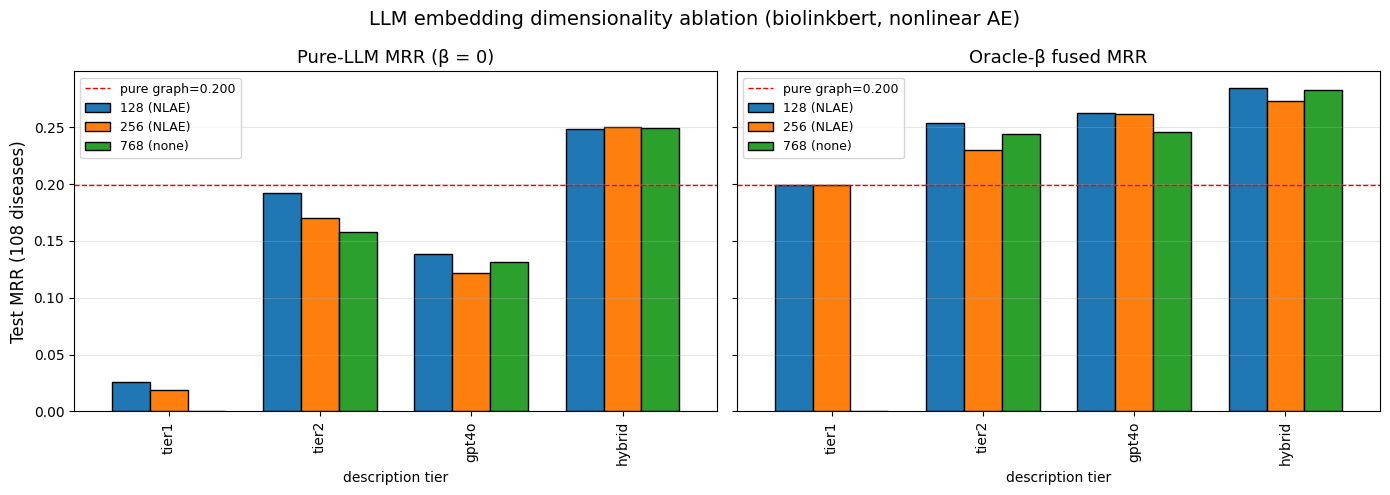

Saved -> results/dim_ablation_256_vs_128_vs_768.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Panel 1: pure-LLM (β=0) MRR
piv1 = test_df.pivot(index="tier", columns="dim", values="pure_LLM_MRR").reindex(index=TIERS, columns=DIM_LABELS)
piv1.plot(kind="bar", ax=axes[0], width=0.75, edgecolor="black")
axes[0].set_title("Pure-LLM MRR (β = 0)", fontsize=13)
axes[0].set_ylabel("Test MRR (108 diseases)", fontsize=12)
axes[0].set_xlabel("description tier")
axes[0].axhline(test_df["pure_LLM_MRR"].dropna().mean() * 0 + pure_graph, color="red", linestyle="--", linewidth=1, label=f"pure graph={pure_graph:.3f}")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: oracle-β MRR
piv2 = test_df.pivot(index="tier", columns="dim", values="oracle_MRR").reindex(index=TIERS, columns=DIM_LABELS)
piv2.plot(kind="bar", ax=axes[1], width=0.75, edgecolor="black")
axes[1].set_title("Oracle-β fused MRR", fontsize=13)
axes[1].set_xlabel("description tier")
axes[1].axhline(pure_graph, color="red", linestyle="--", linewidth=1, label=f"pure graph={pure_graph:.3f}")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle(f"LLM embedding dimensionality ablation ({ENCODER}, nonlinear AE)", fontsize=14)
plt.tight_layout()
Path("results").mkdir(parents=True, exist_ok=True)
plt.savefig("results/dim_ablation_256_vs_128_vs_768.png", dpi=120)
plt.show()
print("Saved -> results/dim_ablation_256_vs_128_vs_768.png")


---
## 6. Conclusion + downstream usage

The 256-d embeddings live at:

```
data/embeddings_256/biolinkbert/{tier1,tier2,gpt4o,hybrid}/nonlinear_ae/
    drug_embeddings.pt        # {"embeddings": (7957, 256), "node_indices": [...]}
    phenotype_embeddings.pt   # {"embeddings": (3518, 256), "node_indices": [...]}
    ae_encoder.pt
    ae_decoder.pt
    ae_meta.json
    projection_fit_info.json
```

To consume in a Phase 3 feature-level fusion module:

```python
import torch
drug = torch.load("data/embeddings_256/biolinkbert/hybrid/nonlinear_ae/drug_embeddings.pt",
                  map_location=device, weights_only=False)
emb_text = drug["embeddings"]            # (7957, 256), L2-normalized
node_ids = drug["node_indices"]          # sorted ascending; aligns with sorted(supervision["drug_indices"])
```

The aligned `node_indices` ordering matches `np.array(sorted(drug_indices))`,
so feature-level fusion can index into both `node_embs[graph]` and
`emb_text[i]` by the same position without remapping.

**Decision rule from this ablation**:
- If the 256-d vs 128-d oracle-MRR gap is small (< 0.005), use 256-d for
  Phase 3 since it removes the dim-mismatch headache for free.
- If 256-d clearly underperforms 128-d (> 0.01), the AE bottleneck at 256-d
  may be under-regularized — try widening the hidden layer or adding dropout.
- If 256-d clearly *outperforms* 128-d, that suggests the 128-d bottleneck
  was discarding retrieval-relevant variance and we should consider 256-d
  as the new default for Phase 2a as well.
